# Compress an orbital rotation into fewer Givens rotations

An [orbital rotation](../explanations/orbital-rotation.ipynb) on `norb` orbitals can be implemented as a network of Givens rotations arranged in a brickwork pattern of up to `norb` layers (see [ffsim.linalg.givens_decomposition](../api/stubs/ffsim.linalg.givens_decomposition.rst#ffsim.linalg.givens_decomposition)). On hardware, each Givens rotation becomes a two-qubit gate, so a full decomposition uses up to $\binom{\text{norb}}{2}$ of them.

Passing `max_layers` (or `max_givens`) requests a *compressed* decomposition: it keeps only the first few layers of the brickwork pattern and numerically optimizes their angles to best approximate the original orbital rotation. The same options are accepted by the Qiskit orbital rotation gates ([OrbitalRotationJW](../api/stubs/ffsim.qiskit.OrbitalRotationJW.rst#ffsim.qiskit.OrbitalRotationJW) and [OrbitalRotationSpinlessJW](../api/stubs/ffsim.qiskit.OrbitalRotationSpinlessJW.rst#ffsim.qiskit.OrbitalRotationSpinlessJW)), which pass them straight through to `givens_decomposition`.

## Fewer gates in a Qiskit circuit

To see compression in action, decompose a Qiskit orbital rotation gate into its basis gates and count the two-qubit ($XX+YY$) gates. We use a random orbital rotation on 6 orbitals. Its full decomposition uses $\binom{6}{2} = 15$ Givens rotations, one $XX+YY$ gate each.

We build the gate with [OrbitalRotationSpinlessJW](../api/stubs/ffsim.qiskit.OrbitalRotationSpinlessJW.rst#ffsim.qiskit.OrbitalRotationSpinlessJW), which acts on `norb` qubits. (For a spinful rotation, use [OrbitalRotationJW](../api/stubs/ffsim.qiskit.OrbitalRotationJW.rst#ffsim.qiskit.OrbitalRotationJW), which acts on `2 * norb` qubits and applies the rotation to both spin sectors.)

Gate counts: {'xx_plus_yy': 15, 'p': 6}


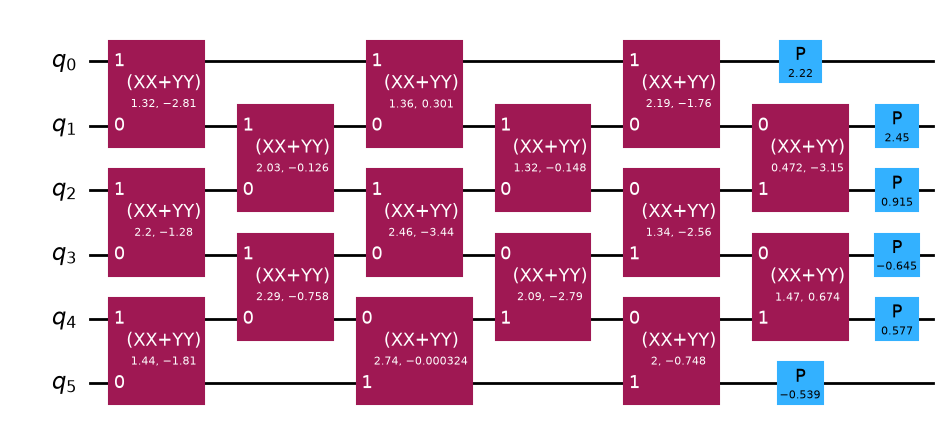

In [1]:
import numpy as np
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.quantum_info import Operator

import ffsim

norb = 6
orbital_rotation = ffsim.random.random_unitary(norb, seed=12345)


def orbital_rotation_circuit(
    orbital_rotation: np.ndarray, *, max_layers: int | None = None
) -> QuantumCircuit:
    """Build a circuit that applies a (possibly compressed) orbital rotation."""
    norb = orbital_rotation.shape[0]
    gate = ffsim.qiskit.OrbitalRotationSpinlessJW(
        norb, orbital_rotation, max_layers=max_layers
    )
    circuit = QuantumCircuit(QuantumRegister(norb, name="q"))
    circuit.append(gate, circuit.qubits)
    return circuit


# Full (exact) decomposition
exact_circuit = orbital_rotation_circuit(orbital_rotation)
circuit = exact_circuit.decompose()
print("Gate counts:", dict(circuit.count_ops()))
circuit.draw("mpl")

Now pass `max_layers=3` to keep only the first three brickwork layers. The resulting gate is an approximation of the orbital rotation, but the decomposed circuit uses far fewer $XX+YY$ gates and has a shorter depth. Passing `max_givens` instead caps the number of Givens rotations directly.

To quantify how good the approximation is, we compare the *unitary of the whole circuit*, which acts on the full $2^{\text{norb}}$-dimensional Hilbert space, to that of the exact circuit. We use the Hilbert–Schmidt infidelity

$$
1 - \left| \frac{\mathrm{Tr}(U^\dagger V)}{D} \right|^2,
$$

where $U$ and $V$ are the exact and compressed circuit operators and $D = 2^{\text{norb}}$ is the Hilbert space dimension (0 is exact, 1 is orthogonal). We compute each circuit's unitary with Qiskit's [Operator](https://quantum.cloud.ibm.com/docs/api/qiskit/qiskit.quantum_info.Operator).

Gate counts: {'xx_plus_yy': 8, 'p': 6}
Infidelity: 0.345872964398674


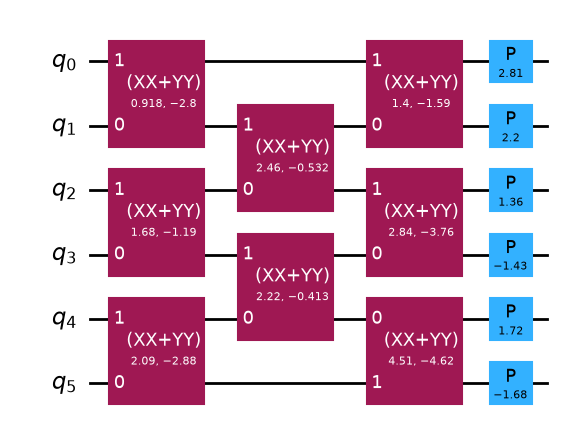

In [2]:
def circuit_infidelity(
    exact_circuit: QuantumCircuit, compressed_circuit: QuantumCircuit
) -> float:
    """Hilbert-Schmidt infidelity between two circuits' unitaries."""
    exact = Operator(exact_circuit).data
    compressed = Operator(compressed_circuit).data
    dim = exact.shape[0]
    overlap = np.vdot(exact, compressed) / dim
    return 1 - abs(overlap) ** 2


# Compressed decomposition
compressed_circuit = orbital_rotation_circuit(orbital_rotation, max_layers=3)
circuit = compressed_circuit.decompose()
print("Gate counts:", dict(circuit.count_ops()))
print("Infidelity:", circuit_infidelity(exact_circuit, compressed_circuit))
circuit.draw("mpl")

How effective the compression is depends on the orbital rotation. A random rotation is nearly incompressible, so the example above produces a circuit whose effect is far from the original circuit, reflected in the large infidelity. The rest of this notebook explores the compressibility of orbital rotations in two practical examples.

## Compressibility of orbital rotations

Compression is approximate, so the natural follow-up question is how much accuracy you give up for the reduced gate count. As above, we measure the error as the Hilbert–Schmidt infidelity

$$
1 - \left| \frac{\mathrm{Tr}(U^\dagger V)}{D} \right|^2
$$

between the exact circuit's unitary $U$ and the compressed circuit's unitary $V$, both acting on the full $D = 2^{\text{norb}}$-dimensional Hilbert space (0 is exact, 1 is orthogonal). We reuse the `orbital_rotation_circuit` and `circuit_infidelity` helpers defined above.

Each example below sweeps `max_layers` from 0 (only the diagonal phases, no Givens rotations) up to `norb - 1` and records the infidelity.

In [3]:
import matplotlib.pyplot as plt
import scipy.linalg

### Time evolution of a sparse quadratic Hamiltonian

The first example is the orbital rotation $e^{-i \Delta t\, h}$ generated by time evolution under a nearest-neighbor hopping Hamiltonian $h$. For short times the rotation is close to the identity and mixes only neighboring orbitals, so a few brickwork layers capture it well. As $\Delta t$ grows, the rotation becomes more delocalized and more layers are needed to reach the same accuracy.

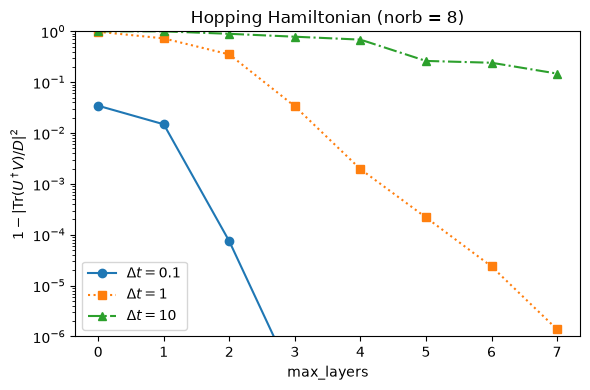

In [4]:
norb = 8
ham = -np.diag(np.ones(norb - 1), k=1) - np.diag(np.ones(norb - 1), k=-1)

time_steps = [1e-1, 1, 10]
orbital_rotations = [
    scipy.linalg.expm(-1j * time_step * ham) for time_step in time_steps
]

infidelities = np.zeros((len(orbital_rotations), norb))
for row, orbital_rotation in enumerate(orbital_rotations):
    exact_circuit = orbital_rotation_circuit(orbital_rotation)
    for max_layers in range(norb):
        compressed_circuit = orbital_rotation_circuit(
            orbital_rotation, max_layers=max_layers
        )
        infidelities[row, max_layers] = circuit_infidelity(
            exact_circuit, compressed_circuit
        )

markers = ["o", "s", "^"]
linestyles = ["-", ":", "-."]
fig, ax = plt.subplots(figsize=(6, 4))
for time_step, row, marker, linestyle in zip(
    time_steps, infidelities, markers, linestyles
):
    label = rf"$\Delta t = {time_step}$"
    ax.plot(range(norb), row, marker=marker, linestyle=linestyle, label=label)

ax.set_yscale("log")
ax.set_ylim(1e-6, 1)
ax.set_xlabel("max_layers")
ax.set_ylabel(r"$1 - |\mathrm{Tr}(U^\dagger V) / D|^2$")
ax.legend()
ax.set_title(f"Hopping Hamiltonian (norb = {norb})")

fig.tight_layout()

### Orbital rotations from a double factorization

The second example uses the orbital rotations that appear in the [double factorization](../explanations/double-factorized.ipynb) of a molecular Hamiltonian, here obtained from the [UCJOpSpinBalanced](../api/stubs/ffsim.UCJOpSpinBalanced.rst#ffsim.UCJOpSpinBalanced) ansatz for N$_2$. Unlike the hopping example, these rotations are dense and generic, so compression buys much less: the infidelity stays near 1 until nearly the full brickwork pattern is kept.

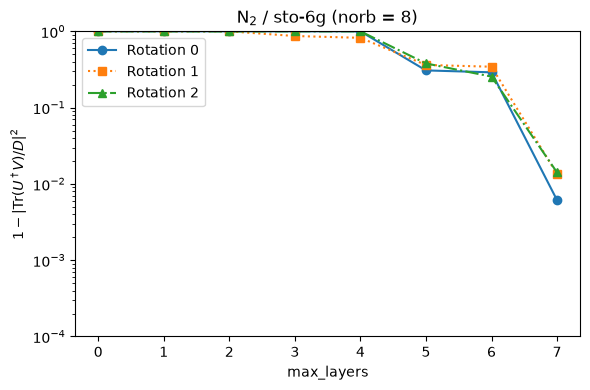

In [5]:
import pyscf.cc
import pyscf.gto
import pyscf.scf

bond_distance = 1.2
basis = "sto-6g"
mol = pyscf.gto.Mole()
mol.build(
    atom=[("N", (-0.5 * bond_distance, 0, 0)), ("N", (0.5 * bond_distance, 0, 0))],
    basis=basis,
    symmetry="Dooh",
    verbose=0,
)
scf = pyscf.scf.RHF(mol)
scf.kernel()

active_space = list(range(2, mol.nao_nr()))
norb = len(active_space)
ccsd = pyscf.cc.RCCSD(
    scf, frozen=[i for i in range(mol.nao_nr()) if i not in active_space]
)
ccsd.kernel()

ucj_op = ffsim.UCJOpSpinBalanced.from_t_amplitudes(t2=ccsd.t2, n_reps=3, optimize=True)
orbital_rotations = ucj_op.orbital_rotations

infidelities = np.zeros((len(orbital_rotations), norb))
for row, orbital_rotation in enumerate(orbital_rotations):
    exact_circuit = orbital_rotation_circuit(orbital_rotation)
    for max_layers in range(norb):
        compressed_circuit = orbital_rotation_circuit(
            orbital_rotation, max_layers=max_layers
        )
        infidelities[row, max_layers] = circuit_infidelity(
            exact_circuit, compressed_circuit
        )

markers = ["o", "s", "^"]
linestyles = ["-", ":", "-."]
fig, ax = plt.subplots(figsize=(6, 4))
for i, (row, marker, linestyle) in enumerate(zip(infidelities, markers, linestyles)):
    label = f"Rotation {i}"
    ax.plot(range(norb), row, marker=marker, linestyle=linestyle, label=label)

ax.set_yscale("log")
ax.set_ylim(1e-4, 1)
ax.set_xlabel("max_layers")
ax.set_ylabel(r"$1 - |\mathrm{Tr}(U^\dagger V) / D|^2$")
ax.legend()
ax.set_title(f"N$_2$ / {basis} (norb = {norb})")

fig.tight_layout()

## Compressibility of Slater determinant preparation

The same compression option is available for [Slater determinant preparation](../explanations/orbital-rotation.ipynb). A Slater determinant is obtained by applying an orbital rotation to an electronic configuration, and ffsim prepares it with a decomposition that is specialized for state preparation rather than implementing the full orbital rotation. For `norb` orbitals with `m` occupied, this decomposition uses at most $m(\text{norb} - m)$ Givens rotations arranged in a diamond-shaped pattern of $\text{norb} - 1$ layers, compared to $\binom{\text{norb}}{2}$ Givens rotations in `norb` layers for a full orbital rotation. Passing `max_layers` (or `max_givens`) requests a compressed decomposition, exactly as for orbital rotations. The Qiskit gates [PrepareSlaterDeterminantJW](../api/stubs/ffsim.qiskit.PrepareSlaterDeterminantJW.rst#ffsim.qiskit.PrepareSlaterDeterminantJW) and [PrepareSlaterDeterminantSpinlessJW](../api/stubs/ffsim.qiskit.PrepareSlaterDeterminantSpinlessJW.rst#ffsim.qiskit.PrepareSlaterDeterminantSpinlessJW) accept these options and pass them to [ffsim.linalg.givens_decomposition_slater](../api/stubs/ffsim.linalg.givens_decomposition_slater.rst#ffsim.linalg.givens_decomposition_slater).

Because the gate prepares a *state* from the all-zeros state (rather than implementing a unitary), we measure the error as the state infidelity

$$
1 - \left| \langle \psi_\text{exact} \vert \psi_\text{compressed} \rangle \right|^2
$$

between the states prepared by the exact and compressed circuits (0 is exact, 1 is orthogonal).

As an example, we prepare the ground state of a quadratic (non-interacting) hopping Hamiltonian, which is the Slater determinant occupying its lowest `norb // 2` single-particle eigenstates. The orbital rotation is the matrix of eigenvectors of the hopping matrix. We compare two hopping ranges: nearest-neighbor and nearest- plus next-nearest-neighbor. As before, we sweep `max_layers` from 0 (only the initial electronic configuration, no Givens rotations) up to `norb - 1` and record the infidelity.

In [6]:
from collections.abc import Sequence

from qiskit.quantum_info import Statevector


def slater_prep_circuit(
    norb: int,
    occupied_orbitals: Sequence[int],
    orbital_rotation: np.ndarray,
    *,
    max_layers: int | None = None,
) -> QuantumCircuit:
    """Build a circuit that prepares a (possibly compressed) Slater determinant."""
    gate = ffsim.qiskit.PrepareSlaterDeterminantSpinlessJW(
        norb, occupied_orbitals, orbital_rotation, max_layers=max_layers
    )
    circuit = QuantumCircuit(QuantumRegister(norb, name="q"))
    circuit.append(gate, circuit.qubits)
    return circuit


def state_infidelity(
    exact_circuit: QuantumCircuit, compressed_circuit: QuantumCircuit
) -> float:
    """State infidelity between the states prepared by two circuits."""
    exact = np.array(Statevector(exact_circuit))
    compressed = np.array(Statevector(compressed_circuit))
    return 1 - abs(np.vdot(exact, compressed)) ** 2

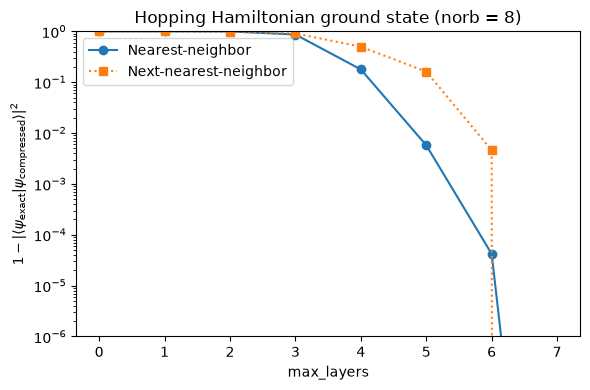

In [7]:
norb = 8
occupied_orbitals = range(norb // 2)
ham_nearest_neighbor = -np.diag(np.ones(norb - 1), k=1) - np.diag(
    np.ones(norb - 1), k=-1
)
ham_next_nearest_neighbor = (
    ham_nearest_neighbor
    - np.diag(np.ones(norb - 2), k=2)
    - np.diag(np.ones(norb - 2), k=-2)
)

# The columns of the eigenvector matrix are the natural orbitals; occupying the
# lowest norb // 2 of them prepares the ground state of the hopping Hamiltonian.
_, orbital_rotation_nn = np.linalg.eigh(ham_nearest_neighbor)
_, orbital_rotation_nnn = np.linalg.eigh(ham_next_nearest_neighbor)
orbital_rotations = [orbital_rotation_nn, orbital_rotation_nnn]
labels = ["Nearest-neighbor", "Next-nearest-neighbor"]

infidelities = np.zeros((len(orbital_rotations), norb))
for row, orbital_rotation in enumerate(orbital_rotations):
    exact_circuit = slater_prep_circuit(norb, occupied_orbitals, orbital_rotation)
    for max_layers in range(norb):
        compressed_circuit = slater_prep_circuit(
            norb, occupied_orbitals, orbital_rotation, max_layers=max_layers
        )
        infidelities[row, max_layers] = state_infidelity(
            exact_circuit, compressed_circuit
        )

markers = ["o", "s"]
linestyles = ["-", ":"]
fig, ax = plt.subplots(figsize=(6, 4))
for label, row, marker, linestyle in zip(labels, infidelities, markers, linestyles):
    ax.plot(range(norb), row, marker=marker, linestyle=linestyle, label=label)

ax.set_yscale("log")
ax.set_ylim(1e-6, 1)
ax.set_xlabel("max_layers")
ax.set_ylabel(
    r"$1 - |\langle \psi_\mathrm{exact} | \psi_\mathrm{compressed} \rangle|^2$"
)
ax.legend()
ax.set_title(f"Hopping Hamiltonian ground state (norb = {norb})")

fig.tight_layout()